In [1]:
# ============================================================
#  Assignment 3 — Common Setup
#  每個組員在自己的 section 前先跑這整塊，之後各自加模型即可
# ============================================================

# ---------- 安裝 ----------
!pip install ucimlrepo -q

# ---------- Imports ----------
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ---------- 全域設定 ----------
RANDOM_SEED = 2026

# ---------- 資料載入 ----------
sonar = fetch_ucirepo(id=151)
X = sonar.data.features.values          # shape: (208, 60)
y_raw = sonar.data.targets.iloc[:, 0]

le = LabelEncoder()
y = le.fit_transform(y_raw)             # M=1, R=0 (按字母排)
print("X shape :", X.shape)
print("Classes :", le.classes_, "→ encoded as", list(range(len(le.classes_))))
print(pd.Series(y_raw).value_counts().to_string())

# ---------- Cross-Validation 設定 ----------
# 5-fold × 5 repeats = 25 個 fold（dataset 小，需要 repeated CV）
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_SEED,
)

# ---------- Scoring ----------
SCORING = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

# ---------- 通用執行函數 ----------
def run_model(name, pipeline, param_grid, inner_cv=3):
    """
    對單一模型跑 nested CV：
      外層 = outer_cv（25 folds）做 performance estimation
      內層 = GridSearchCV（inner_cv folds）做 hyperparameter tuning

    Parameters
    ----------
    name       : str          模型名稱（用於顯示）
    pipeline   : Pipeline     sklearn Pipeline
    param_grid : dict         GridSearchCV 的參數網格
    inner_cv   : int          內層 CV fold 數（預設 3）

    Returns
    -------
    dict  包含 model name 和各指標 mean/std
    """
    print(f"▶ Running: {name}")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )
    cv_result = cross_validate(
        search,
        X, y,
        cv=outer_cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {"Model": name}
    for metric in SCORING:
        scores = cv_result[f"test_{metric}"]
        row[f"{metric}_mean"] = round(np.mean(scores), 4)
        row[f"{metric}_std"]  = round(np.std(scores),  4)
    return row


# ---------- 結果彙整 & 顯示 ----------
def show_results(results_list):
    """
    傳入 list of dict（每個 run_model 的回傳值），
    輸出格式化的 DataFrame，欄位用 mean ± std 呈現。
    """
    df = pd.DataFrame(results_list)
    display_df = pd.DataFrame({"Model": df["Model"]})
    for metric in SCORING:
        display_df[metric] = (
            df[f"{metric}_mean"].map("{:.4f}".format)
            + " ± "
            + df[f"{metric}_std"].map("{:.4f}".format)
        )
    display_df = display_df.sort_values(
        by="Model"          # 之後可改成按 f1_mean 排序
    ).reset_index(drop=True)
    try:
        from IPython.display import display
        display(display_df)
    except ImportError:
        print(display_df.to_string(index=False))
    return df   # 回傳原始數值 df 方便後續畫圖


# ---------- Confusion Matrix 工具 ----------
def plot_confusion_matrix(model_name, pipeline, param_grid):
    """
    對整個 dataset 跑一次 GridSearchCV 找最佳參數，
    再畫 confusion matrix（注意：這只是視覺化用，不算 test performance）。
    用法：plot_confusion_matrix("RBF-SVM", pipeline, param_grid)
    """
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X, y)
    y_pred = search.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}\n(best params on full data)")
    plt.tight_layout()
    plt.show()


# ============================================================
#  以下各組員各自貼上自己的模型定義 + 呼叫 run_model
#
#  範例（組員1）：
#
#  pipeline_lr = Pipeline([
#      ("scaler", StandardScaler()),
#      ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
#  ])
#  param_grid_lr = {"clf__C": [0.01, 0.1, 1, 10]}
#  result_lr = run_model("Logistic Regression", pipeline_lr, param_grid_lr)
#
#  最後：
#  all_results = [result_lr, result_knn, result_dt, ...]
#  raw_df = show_results(all_results)
# ============================================================

X shape : (208, 60)
Classes : ['M' 'R'] → encoded as [0, 1]
class
M    111
R     97


In [2]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
])
param_grid_lr = {"clf__C": [0.01, 0.1, 1, 10]}

result_lr = run_model("Logistic Regression", pipeline_lr, param_grid_lr)

▶ Running: Logistic Regression


In [3]:
# 顯示結果表格
raw_df = show_results([result_lr])

,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.7721 ± 0.0511,0.7639 ± 0.0697,0.7480 ± 0.1026,0.7511 ± 0.0658,0.8489 ± 0.0533


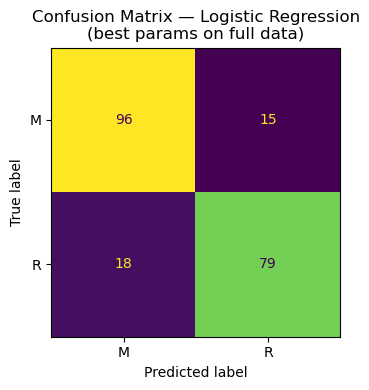

In [4]:
# 顯示 Confusion Matrix（視覺化用）
plot_confusion_matrix("Logistic Regression", pipeline_lr, param_grid_lr)

▶ Running: Decision Tree


,Model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.7134 ± 0.0626,0.7121 ± 0.0864,0.6723 ± 0.0895,0.6859 ± 0.0633,0.7341 ± 0.0689


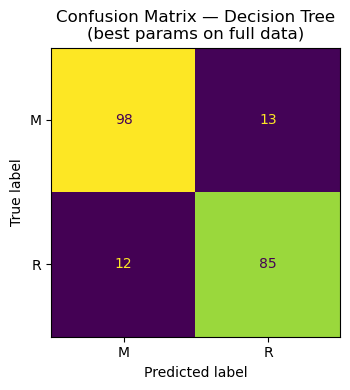

In [7]:
from sklearn.tree import DecisionTreeClassifier
# DecisionTree 不需要 StandardScaler
pipeline_dt = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=RANDOM_SEED))
])

param_grid_dt = {
    "clf__max_depth": [None, 3, 5, 10],
    "clf__min_samples_leaf": [1, 3, 5]
}

result_dt = run_model("Decision Tree", pipeline_dt, param_grid_dt)

show_results([result_dt])
plot_confusion_matrix("Decision Tree", pipeline_dt, param_grid_dt)

▶ Running: Random Forest


,Model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.7134 ± 0.0626,0.7121 ± 0.0864,0.6723 ± 0.0895,0.6859 ± 0.0633,0.7341 ± 0.0689
1,Random Forest,0.8315 ± 0.0661,0.8677 ± 0.0697,0.7541 ± 0.1170,0.8029 ± 0.0869,0.9291 ± 0.0330


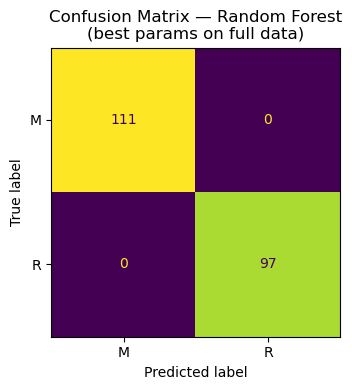

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
pipeline_rf = Pipeline([
    ("clf", RandomForestClassifier(
            random_state=RANDOM_SEED, n_jobs=-1,
        )
    )
])

param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 5, 10]
}

result_rf = run_model("Random Forest", pipeline_rf, param_grid_rf)

show_results([result_dt, result_rf])
plot_confusion_matrix("Random Forest", pipeline_rf, param_grid_rf)

4. Does Random Forest outperform a single Decision Tree?

是的，根據實驗結果，Random Forest 明顯優於單一 Decision Tree。

| Model         | Accuracy        | F1-score        | ROC-AUC         |
| ------------- | --------------- | --------------- | --------------- |
| Decision Tree | 0.7134 ± 0.0626 | 0.6859 ± 0.0633 | 0.7341 ± 0.0689 |
| Random Forest | 0.8315 ± 0.0661 | 0.8029 ± 0.0869 | 0.9291 ± 0.0330 |

其中 ROC-AUC 提升最明顯，代表 Random Forest 對 Mine 與 Rock 的區分能力更強，整體分類邊界更加穩定。

Random Forest 的 ROC-AUC standard deviation 只有 ±0.0330，比 Decision Tree 的 ±0.0689 低，表示其在不同 cross-validation folds 間具有更穩定的表現與更好的泛化能力。

Random Forest 表現較好的主要原因如下：

1. Bagging 降低 overfitting
   Decision Tree 容易對訓練資料過度擬合，尤其 Sonar dataset 僅有 208 筆資料且特徵維度高達 60 維。Random Forest 透過 bootstrap sampling 建立多棵樹，再以投票方式整合結果，可有效降低 variance 與 overfitting。

2. Feature randomness 增加模型多樣性
   Random Forest 在每次 split 時只會隨機選擇部分 features，因此不同樹會學到不同 decision boundaries。這種隨機性可降低模型間 correlation，使 ensemble 結果更穩定。

3. Sonar dataset 具有非線性特性
   Sonar dataset 的 Mine 與 Rock 並非線性可分，且資料量小、noise 較明顯。單一 Decision Tree 很容易受到少量樣本影響而產生不穩定切割；Random Forest 則能透過多棵樹平均化降低這種問題。